## ATMS 523 Module 6 Assignment

Haley Schmidt

11/16/2025

### 1. Aggregate the tornado data over the following states into a monthly count of tornadoes:

In [ ]:
# Setup
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.inspection import permutation_importance
import shap

# SSL setup
# Dissable SSL verification
import os, ssl, certifi

# Restore the default HTTPS context
ssl._create_default_https_context = ssl.create_default_context

# Direct OpenSSL to CA certs
os.environ["SSL_CERT_FILE"] = certifi.where()

# custom default context using certifi
def _certifi_context(*args, **kwargs):
    return ssl.create_default_context(cafile=certifi.where(), *args, **kwargs)

ssl._create_default_https_context = _certifi_context

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load tornado data
url = "https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv"
tornado = pd.read_csv(url)

In [ ]:
# datetime column
tornado["date"] = pd.to_datetime(
    tornado[["yr", "mo", "dy"]].rename(columns={"yr":"year", "mo":"month", "dy":"day"})
)

tornado_il = tornado[tornado["st"] == "IL"].copy()

# set datetime index
tornado_il = tornado_il.set_index("date")

# count monthlu tornadoes
tornado_il_monthly = tornado_il.resample("MS").size().to_frame(name="tornado_count")

print(tornado_il_monthly)

            tornado_count
date                     
1950-01-01              2
1950-02-01              0
1950-03-01              1
1950-04-01              0
1950-05-01              0
...                   ...
2021-08-01             16
2021-09-01              0
2021-10-01             10
2021-11-01              0
2021-12-01              8

[864 rows x 1 columns]


### 2. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [8]:
enso = pd.read_csv('https://www.atmos.illinois.edu/~snesbitt/soi.dat',sep=r'\s+',header=None,skiprows=4,skipfooter=0, engine='python')
pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',sep=r'\s+',header=None,skiprows=2, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')

In [31]:
enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

enso_new['Date'] = pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values

newdf_all = pd.concat(
    [enso_new, pdo_new, nao_new, ao_new],
    axis=1
)

start = tornado_il_monthly.index.min()
end   = tornado_il_monthly.index.max()

newdf = newdf_all.loc[start:end]
df = tornado_il_monthly.join(newdf, how="inner")
df


/var/folders/yn/jk_z3jjj5bq9hv1j210z7_800000gn/T/ipykernel_26175/2149095465.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
/var/folders/yn/jk_z3jjj5bq9hv1j210z7_800000gn/T/ipykernel_26175/2149095465.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
/var/folders/yn/jk_z3jjj5bq9hv1j210z7_800000gn/T/ipykernel_26175/2149095465.py:18: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See

,tornado_count,ENSO,PDO,NAO,AO
date,,,,,
1950-01-01,2,NaN,-1.61,0.92,-0.060
1950-02-01,0,NaN,-2.17,0.40,0.627
1950-03-01,1,NaN,-1.89,-0.36,-0.008
1950-04-01,0,NaN,-1.99,0.73,0.555
1950-05-01,0,NaN,-3.19,-0.59,0.072
...,...,...,...,...,...
2021-08-01,16,0.6,-0.95,-0.28,-0.209
2021-09-01,0,0.8,-1.96,-0.21,-0.252
2021-10-01,10,0.7,-3.13,-2.29,-0.146


### 3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

In [ ]:
# Random Forest Model
df_model = df.copy()

df_model = df_model.dropna()

X = df_model[["ENSO", "PDO", "NAO", "AO"]]
y = df_model["tornado_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Correlation coefficient 
r, p = pearsonr(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Correlation:", round(r, 3))
print("RMSE:", round(rmse, 3))

Correlation: 0.082
RMSE: 7.864


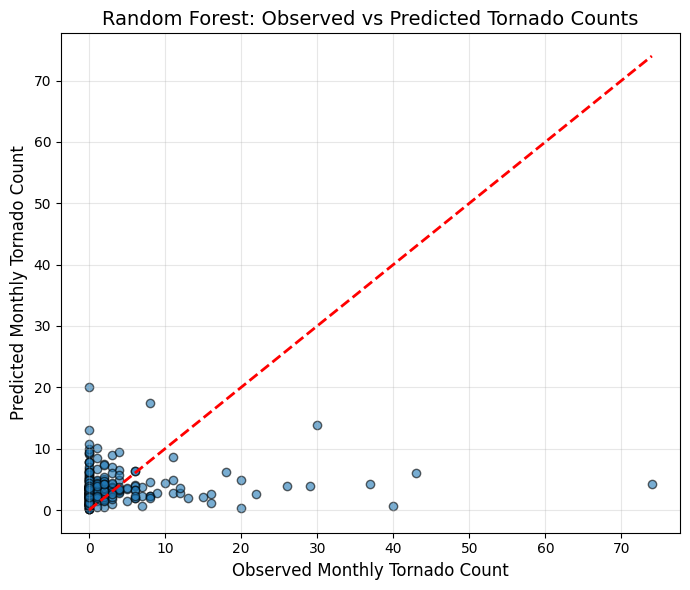

In [ ]:
# Plot rf
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')

lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel("Observed Monthly Tornado Count", fontsize=12)
plt.ylabel("Predicted Monthly Tornado Count", fontsize=12)
plt.title("Random Forest: Observed vs Predicted Tornado Counts", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.

In [ ]:
df_model_h = df.copy().dropna()

df_model_h["month"] = df_model_h.index.month

# One-hot encode month
month_dummies = pd.get_dummies(df_model_h["month"], prefix="month", drop_first=False)

X = pd.concat([df_model_h[["ENSO", "PDO", "NAO", "AO"]], month_dummies], axis=1)
y = df_model_h["tornado_count"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf_month = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf_month.fit(X_train, y_train)

y_pred_month = rf_month.predict(X_test)

r_month, p_month = pearsonr(y_test, y_pred_month)
rmse_month = np.sqrt(mean_squared_error(y_test, y_pred_month))

print("Correlation with month encoding:", round(r_month, 3))
print("RMSE with month encoding:", round(rmse_month, 3))


Correlation with month encoding: 0.26
RMSE with month encoding: 7.609


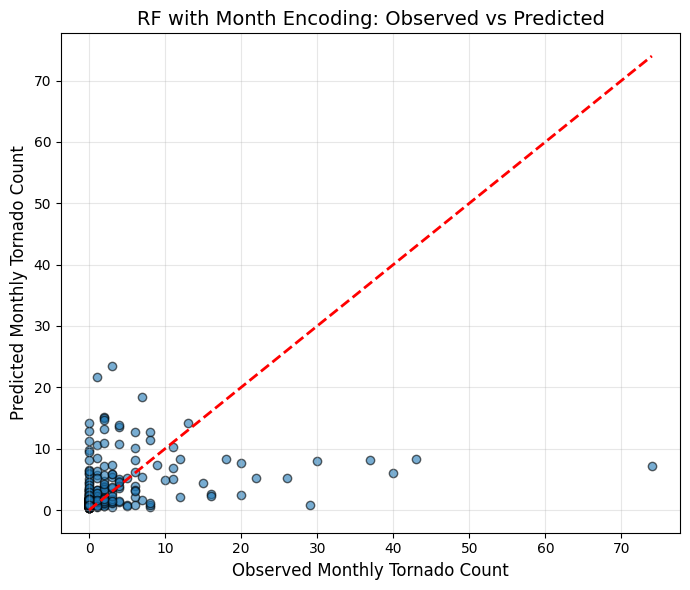

In [ ]:
# Plot one-hot rf
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_month, alpha=0.6, edgecolor='k')

lims = [0, max(y_test.max(), y_pred_month.max())]
plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel("Observed Monthly Tornado Count", fontsize=12)
plt.ylabel("Predicted Monthly Tornado Count", fontsize=12)
plt.title("RF with Month Encoding: Observed vs Predicted", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Perform a feature importance and multipass permutation analysis of your features.


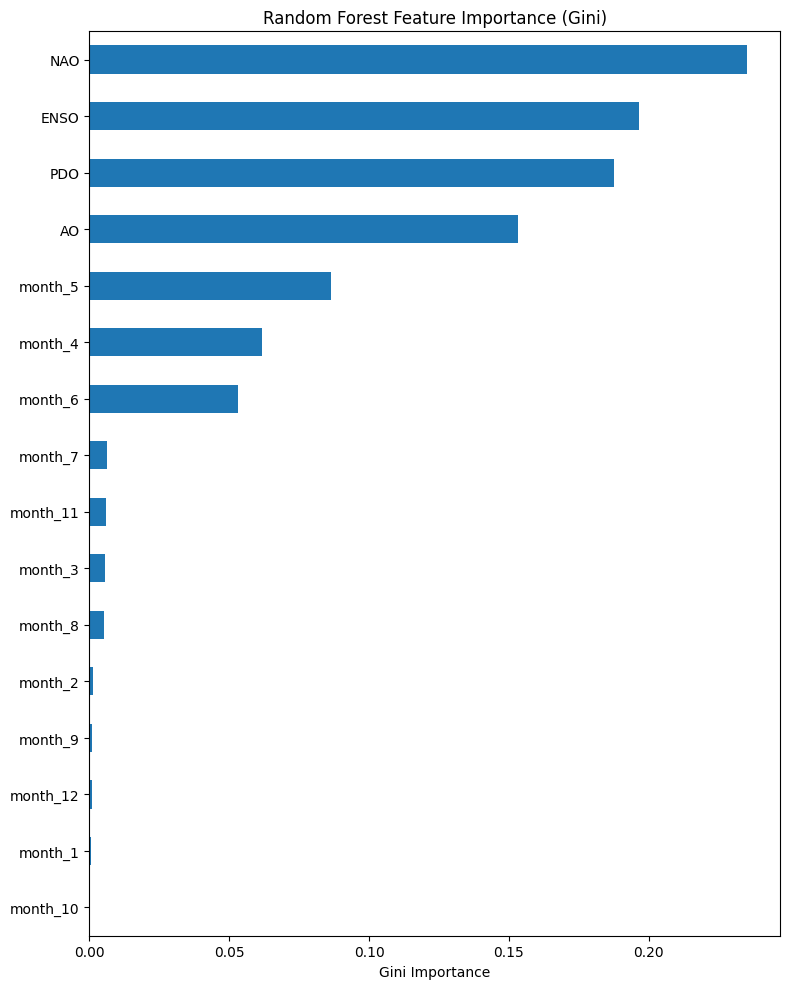

NAO         0.235222
ENSO        0.196445
PDO         0.187468
AO          0.153258
month_5     0.086409
month_4     0.061770
month_6     0.052998
month_7     0.006366
month_11    0.005776
month_3     0.005674
month_8     0.005119
month_2     0.001410
month_9     0.000745
month_12    0.000735
month_1     0.000400
dtype: float64


In [39]:
# feature importance
fi = pd.Series(rf_month.feature_importances_, index=X.columns)
fi_sorted = fi.sort_values(ascending=True) 

plt.figure(figsize=(8,10))
fi_sorted.plot(kind="barh")
plt.xlabel("Gini Importance")
plt.title("Random Forest Feature Importance (Gini)")
plt.tight_layout()
plt.show()

print(fi.sort_values(ascending=False).head(15))


In [ ]:
# multipass permutation function
def multipass_permutation(model, X, y, n_passes=5, n_repeats=30, random_state=42):
    rng = np.random.default_rng(random_state)
    X_work = X.copy()
    features = list(X.columns)
    all_results = []

    for p in range(n_passes):
        perm = permutation_importance(
            model,
            X_work[features],
            y,
            n_repeats=n_repeats,
            random_state=random_state + p,
            n_jobs=-1
        )
        imp_mean = pd.Series(perm.importances_mean, index=features)
        all_results.append(imp_mean)

        # identify and permanently shuffle the most important feature
        top_feature = imp_mean.sort_values(ascending=False).index[0]
        X_work[top_feature] = rng.permutation(X_work[top_feature].values)

        print(f"Pass {p+1}: permuted top feature → {top_feature}")

    result_df = pd.DataFrame(all_results, index=[f"pass_{i+1}" for i in range(n_passes)])
    return result_df

multi_imp = multipass_permutation(rf_month, X_test, y_test, n_passes=5, n_repeats=20)

print(multi_imp) 


Pass 1: permuted top feature → month_6
Pass 2: permuted top feature → month_4
Pass 3: permuted top feature → month_5
Pass 4: permuted top feature → month_5
Pass 5: permuted top feature → PDO
            ENSO       PDO       NAO        AO   month_1   month_2   month_3  \
pass_1  0.047793  0.015133  0.027154 -0.012086  0.000137  0.000018  0.004375   
pass_2  0.048043 -0.023212  0.034371 -0.014406  0.000271 -0.000006 -0.004116   
pass_3 -0.045107  0.056507  0.002121 -0.018246  0.000471 -0.000031  0.001351   
pass_4  0.041873  0.096411  0.040515  0.029596  0.000176 -0.000212 -0.001725   
pass_5  0.022016  0.070898  0.050544  0.026833  0.000571 -0.000141 -0.002085   

         month_4   month_5   month_6   month_7   month_8   month_9  month_10  \
pass_1  0.093224  0.059225  0.124649  0.007071  0.015643 -0.000195  0.000002   
pass_2  0.096486  0.081331 -0.022918  0.004253  0.011215 -0.000547  0.000019   
pass_3 -0.075157  0.076247 -0.026160  0.006183  0.008936 -0.000643  0.000045   
pass_4 -

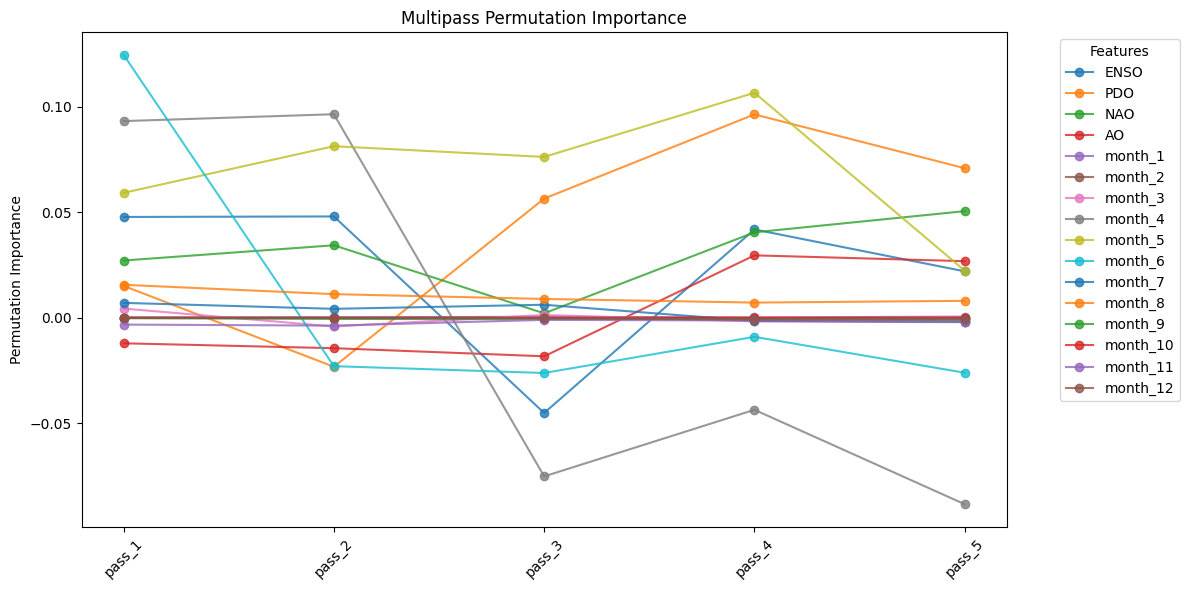

In [53]:
# Plot multipass permutation 
plt.figure(figsize=(12,6))

for col in multi_imp.columns:
    plt.plot(
        multi_imp.index,
        multi_imp[col],
        marker="o",
        alpha=0.8,
        label=str(col)  # <--- FORCE a real label
    )

plt.xticks(rotation=45)
plt.ylabel("Permutation Importance")
plt.title("Multipass Permutation Importance")
plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6. Create a SHAP Summary Plot showing feature importance and feature effects.


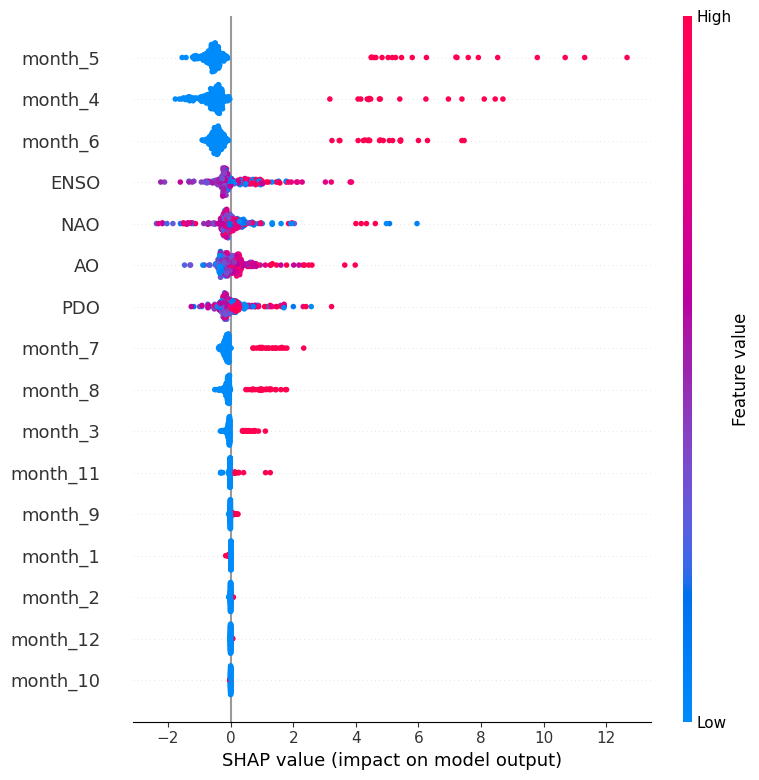

In [ ]:
# SHAP baseline
explainer = shap.TreeExplainer(rf_month)

# SHAP values for the test set
shap_values = explainer.shap_values(X_test)

#plot
shap.summary_plot(shap_values, X_test)

### 7. Create a SHAP Feature Dependence for the ENSO index.


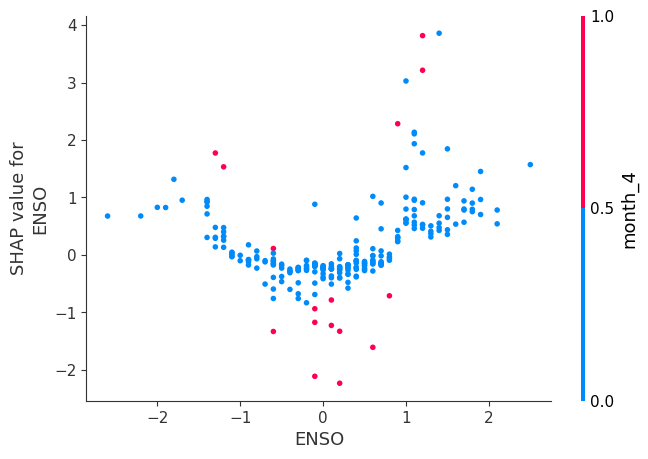

In [ ]:
# SHAP feature dependence plot for ENSO
shap.dependence_plot(
    "ENSO",       
    shap_values,     
    X_test           
)


### 8. Any observations on the importance of the various features in your model from the XAI techniques you tried?


My model consistently showed seasonality as the dominant predictor across all XAI techniques. April through June were identified as the most important features and they were the first removed in the multipass permutation. This indicated a strong annual cycle of tornadoes in Illinois. In comparison, the climate indices had a weaker predictive skill. Gini importance metrics ranked them higher, however their permutation importance were much smaller than the importance of spring months. The climate indices were only ranked higher once seasonal features were permuted away. The SHAP plot for ENSO had a slight nonlinear trend and suggested that ENSO's influence on tornadoes was WEAK. 